In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/data/00100
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

152


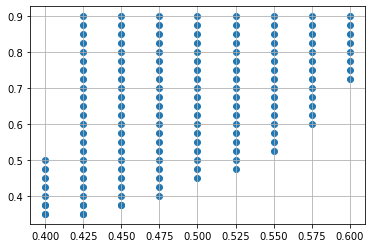

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [8]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'

In [9]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [10]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4000000000000001 0.3750000000000001
-------  14 0.4000000000000001 0.42500000000000016
-------  21 0.47500000000000014 0.4500000000000002
-------  28 0.5250000000000001 0.4750000000000002
-------  35 0.4250000000000001 0.5250000000000002
-------  42 0.4500000000000001 0.5500000000000003
-------  49 0.47500000000000014 0.5750000000000003
-------  56 0.5000000000000002 0.6000000000000003
-------  63 0.5000000000000002 0.6250000000000003
-------  70 0.5000000000000002 0.6500000000000004
-------  77 0.5000000000000002 0.6750000000000004
-------  84 0.5000000000000002 0.7000000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  98 0.47500000000000014 0.7500000000000004
-------  105 0.4500000000000001 0.7750000000000005
-------  112 0.4250000000000001 0.8000000000000005
-------  119 0.6000000000000003 0.8000000000000005
-------  126 0.5750000000000002 0.8250000000000005
-------  133 0.5500000000000003 0.8500000000

In [11]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140 147]


In [12]:
factor_iteration = 20.

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    weights_init[i] = cost.getParams()

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]
    
##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  182.3412555896917
RUN  2 , total integrated cost =  6.524764621163929
RUN  3 , total integrated cost =  0.2747591263084246
RUN  4 , total integrated cost =  0.19999061865180756
RUN  5 , total integrated cost =  0.19487422697102047
RUN  6 , total integrated cost =  0.1932981489428262
RUN  7 , total integrated cost =  0.1913812053424654
RUN  8 , total integrated cost =  0.19040478491151736
RUN  9 , total integrated cost =  0.18180164761076237
RUN  10 , total integrated cost =  0.1817004056364315

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  179 , total integrated cost =  0.17538452070000837
Improved over  179  iterations in  36.344134509563446  seconds by  99.99702859297615  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223366 1.6064366467635345
Problem in initial value trasfer:  tau_exc 17.220111838880012 17.25208476032102
Problem in initial value trasfer:  Vmean_exc -56.62762085634181 -56.627620840584484
weight =  336540.901995241
set cost params:  1.0 0.0 336540.901995241
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5888.509450138673
Gradient descend method:  None
RUN  1 , total integrated cost =  5473.8411665258345
RUN  2 , total integrated cost =  5471.717420053264
RUN  3 , total integrated cost =  5380.287087256387
RUN  4 , total integrated cost =  5329.324662242805
RUN  5 , total integrated cost =  5329.311398670278
RUN  6 , total integrated cost =  5329.299376010931
RUN  7 , total integrated cost =  5329.260094767011
RUN  8 , total

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  24 , total integrated cost =  5315.967431431287
Improved over  24  iterations in  2.779329476878047  seconds by  9.72303812289718  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223366 1.60711945600631
Problem in initial value trasfer:  tau_exc 17.220111838880012 17.244299839579213
Problem in initial value trasfer:  Vmean_exc -56.62669572300119 -56.62670281071722
-------  7 0.4000000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5538.707762167343
Gradient descend method:  None
RUN  0 , total integrated cost =  5538.707762167343
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5538.707762167343
Gradient descend method:  None
RUN  1 , total integrated cost =  38.449988453025085
RUN  2 , total integrated cost =  9.126317510971926
RUN  

...

Control only changes marginally.
RUN  25 , total integrated cost =  22166.548708073995
Improved over  25  iterations in  2.604693775996566  seconds by  5.6035583184675914  percent.
Problem in initial value trasfer:  sigmae_f 1.501065940868336 1.5010658509984938
Problem in initial value trasfer:  tau_exc 21.62329444010742 21.623294877332448
Problem in initial value trasfer:  Vmean_exc -56.70066222424784 -56.70066276398545
-------  147 0.5000000000000002 0.9000000000000006
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18799.793834787204
Gradient descend method:  None
RUN  0 , total integrated cost =  18799.793834787204
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18799.793834787204
Gradient descend method:  None
RUN  1 , total integrated cost =  42.66088664074208
RUN  2 , total integrated cost =  41.7671570780626

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  74 , total integrated cost =  0.7171962009008939
Improved over  74  iterations in  5.192437330260873  seconds by  99.9961850847557  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.757978152188148
weight =  262129.02147518576
set cost params:  1.0 0.0 262129.02147518576
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18768.497527240674
Gradient descend method:  None
RUN  1 , total integrated cost =  18089.709205958025
RUN  2 , total integrated cost =  18065.290296482257
RUN  3 , total integrated cost =  18047.071796732613
RUN  4 , total integrated cost =  18046.49695365915
RUN  5 , total integrated cost =  17767.191750124268
RUN  6 , total integrated cost =  17755.508408661986
RUN  7 , total integrated cost =  17755.49561292414
RUN  8 , total integrated cost =  17755.495610319223
RUN  9 , total integrated cost =  17755.495610282353
RUN  10 , total integrated cost =  17755.495610281163
RUN  11 , total

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  17755.495610281112
Control only changes marginally.
RUN  16 , total integrated cost =  17755.495610281112
Improved over  16  iterations in  1.9444808773696423  seconds by  5.39735221473795  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.757978150134573
Problem in initial value trasfer:  Vmean_exc -56.69192619325477 -56.691928480417396


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


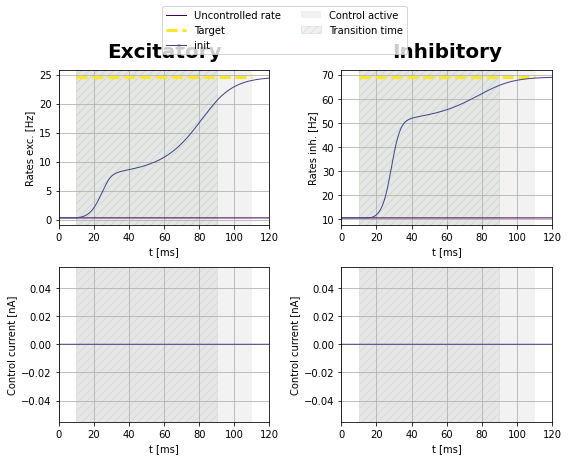

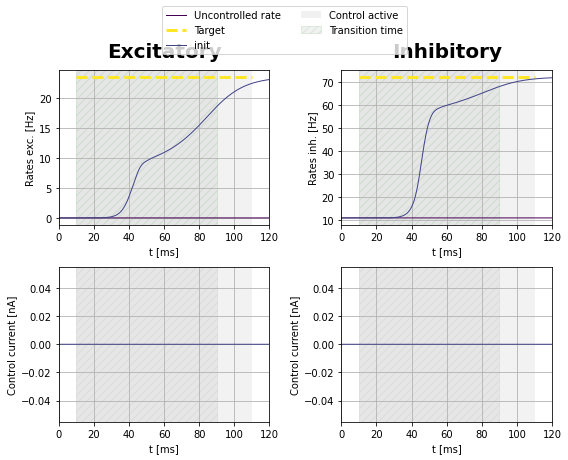

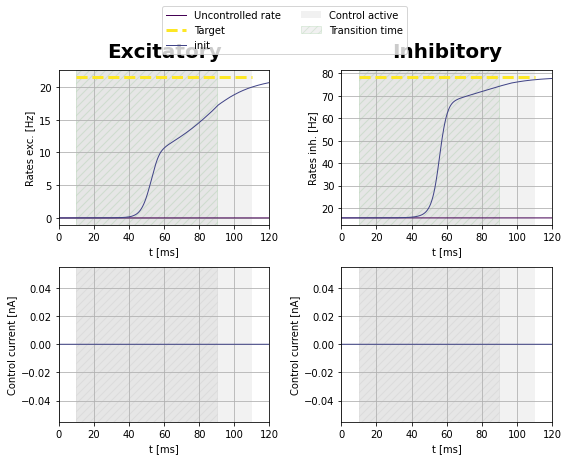

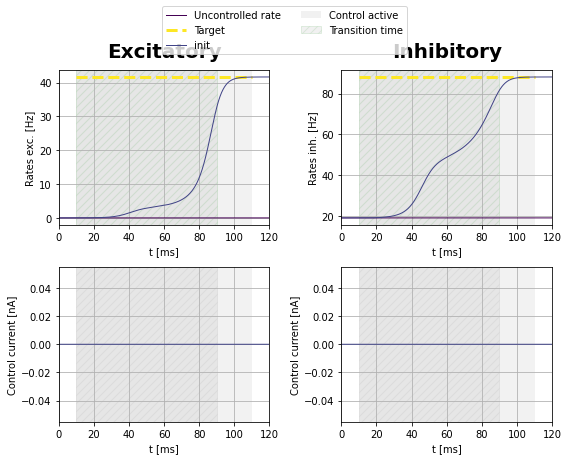

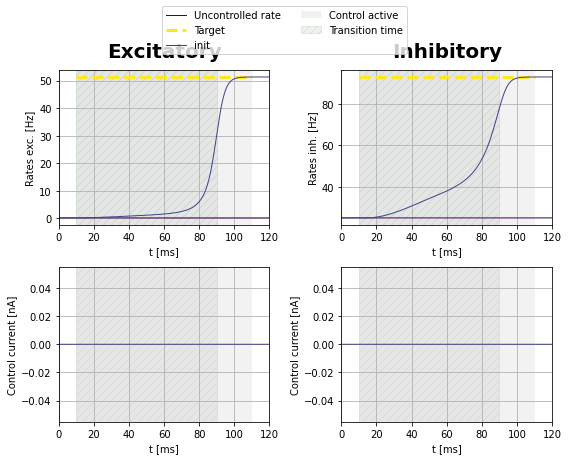

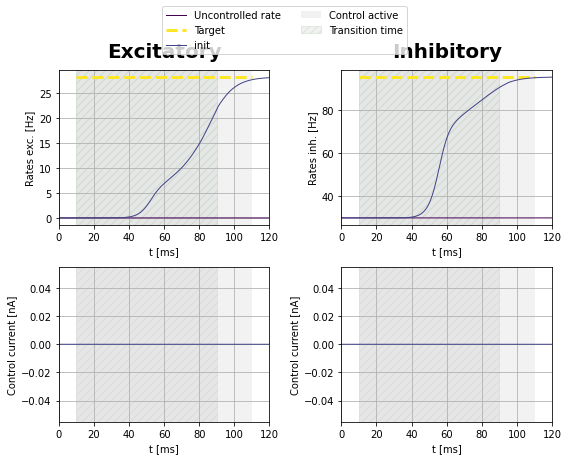

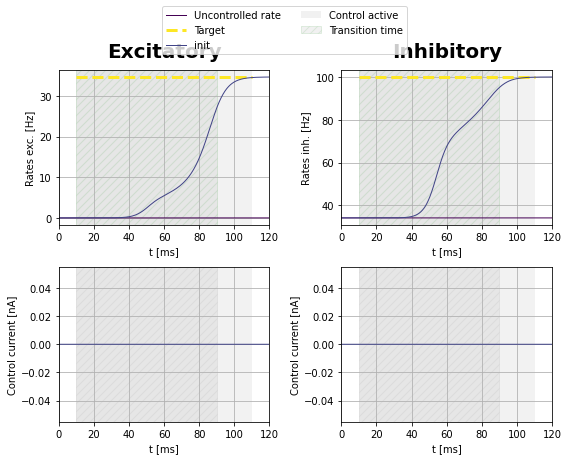

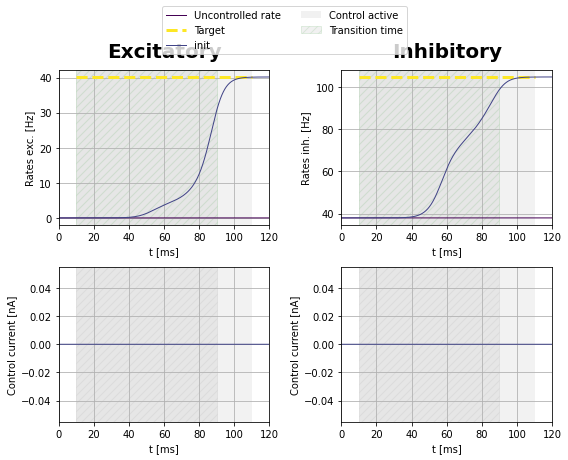

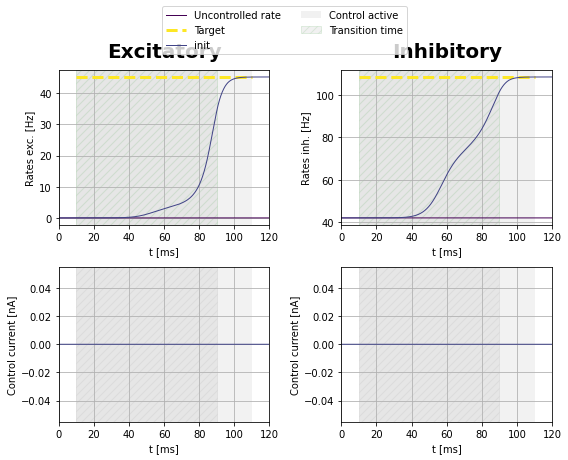

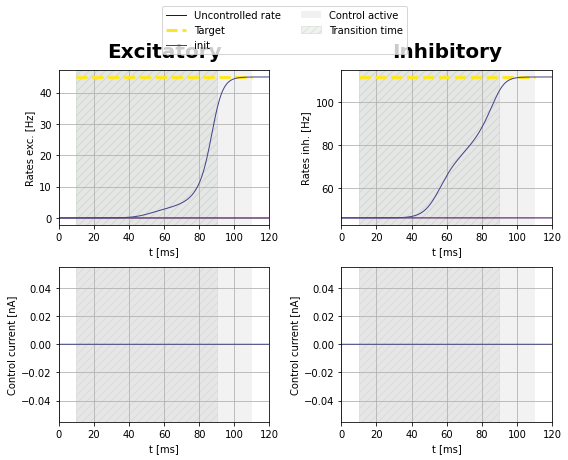

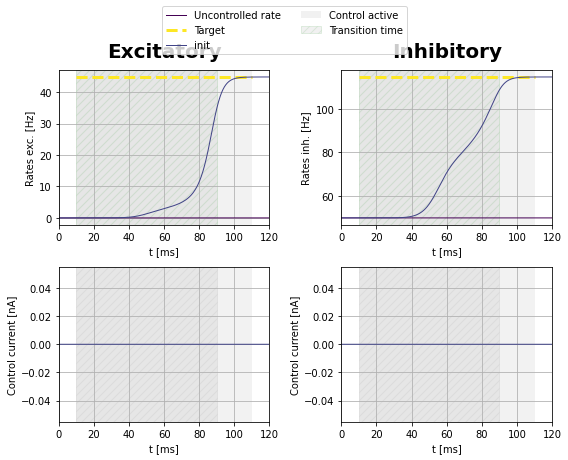

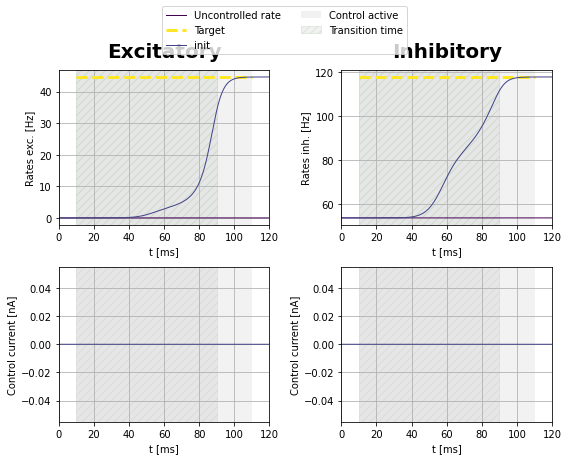

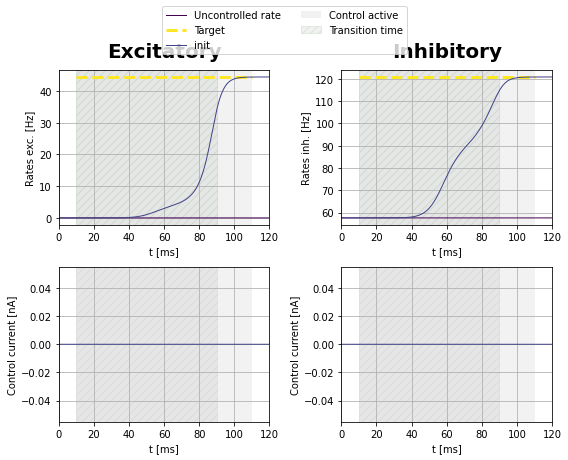

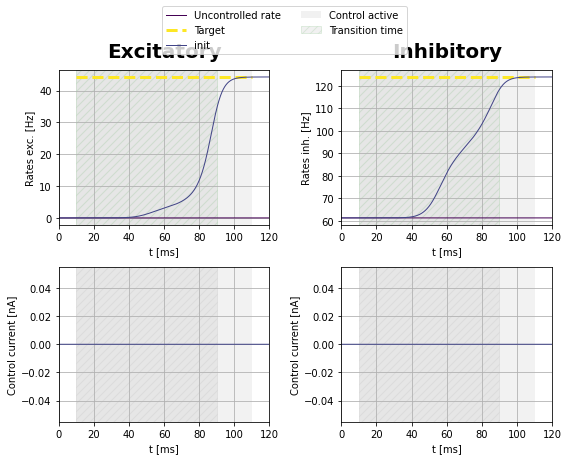

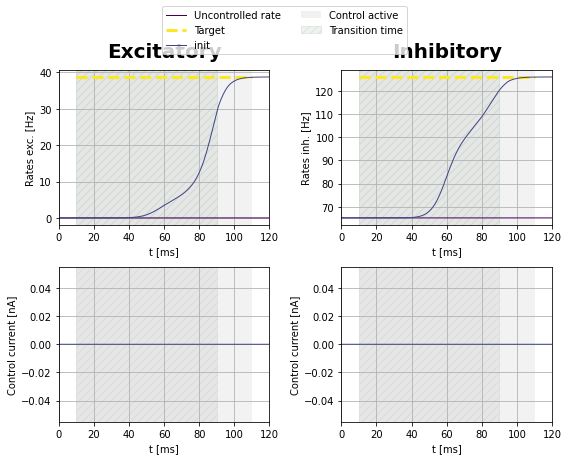

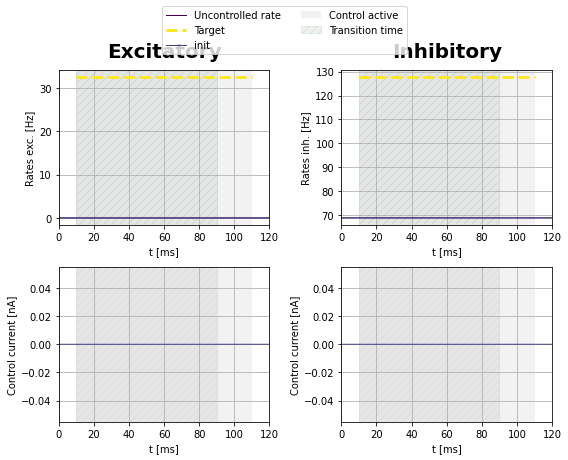

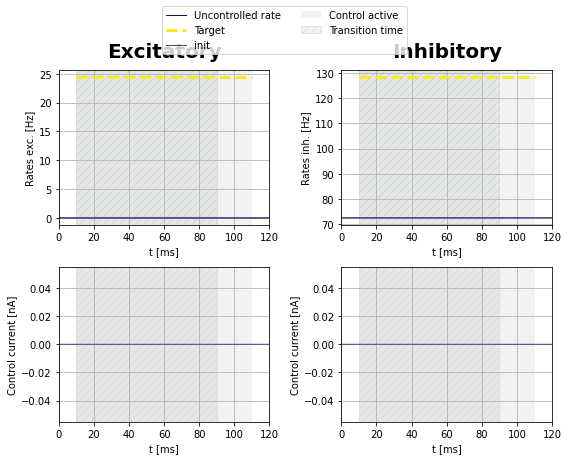

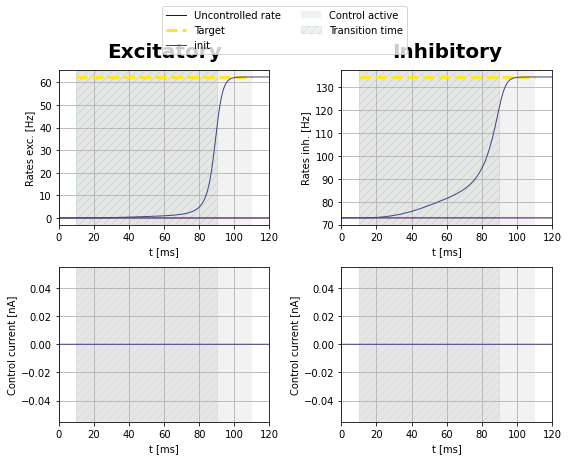

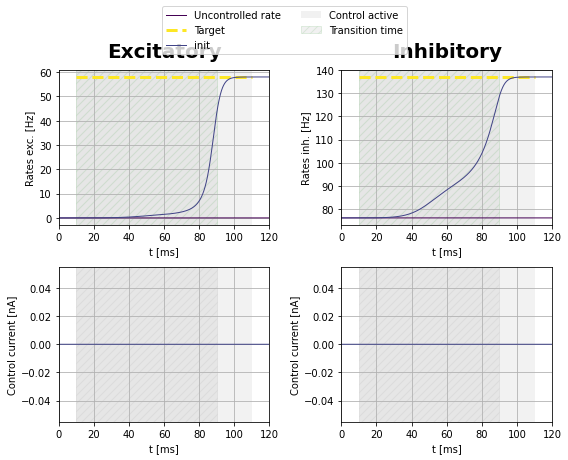

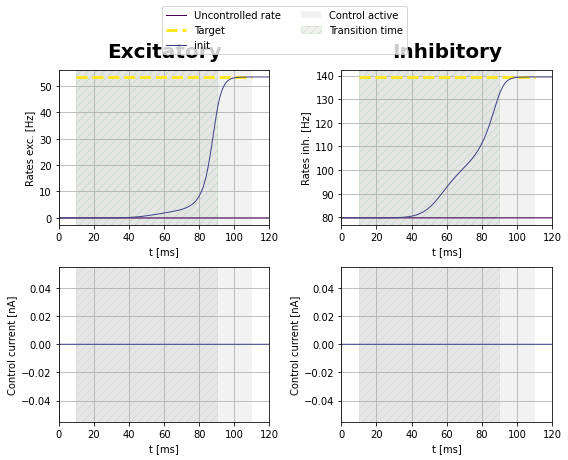

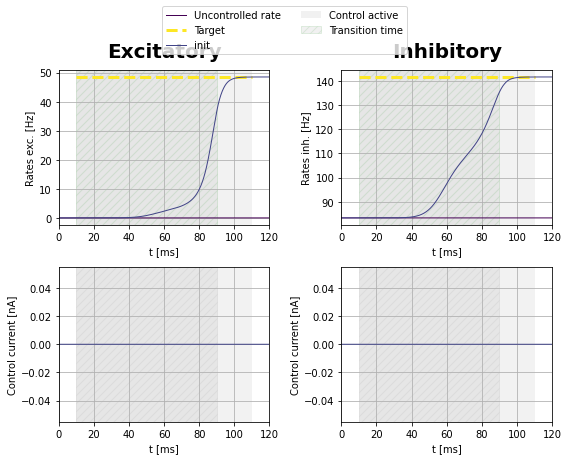

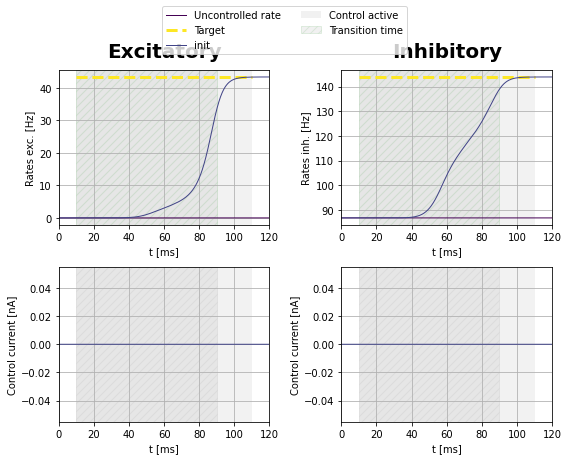

In [13]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [14]:
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    if np.abs(cost_uncontrolled[i] - costnode_init[i][0][0][0]) > 1.:
        continue
        
    print("no solution found for ", i)
    
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    if i != 0:
        control0 = bestControl_init[i-2*i_stepsize][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4000000000000001 0.3750000000000001
-------  14 0.4000000000000001 0.42500000000000016
-------  21 0.47500000000000014 0.4500000000000002
-------  28 0.5250000000000001 0.4750000000000002
-------  35 0.4250000000000001 0.5250000000000002
-------  42 0.4500000000000001 0.5500000000000003
-------  49 0.47500000000000014 0.5750000000000003
-------  56 0.5000000000000002 0.6000000000000003
-------  63 0.5000000000000002 0.6250000000000003
-------  70 0.5000000000000002 0.6500000000000004
-------  77 0.5000000000000002 0.6750000000000004
-------  84 0.5000000000000002 0.7000000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  98 0.47500000000000014 0.7500000000000004
-------  105 0.4500000000000001 0.7750000000000005
no solution found for  105
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10560.262930004306
Gradient descend method:  None
RUN  1 , total in

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  156 , total integrated cost =  1.1859613529495008
Improved over  156  iterations in  13.602800937369466  seconds by  99.98876958499224  percent.
Problem in initial value trasfer:  sigmae_f 1.5013986431983122 1.5014018334641182
Problem in initial value trasfer:  Vmean_exc -56.65537080296478 -56.655376043190444
weight =  89039.23573948482
set cost params:  1.0 0.0 89039.23573948482
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10547.63529916831
Gradient descend method:  None
RUN  1 , total integrated cost =  9984.974273697011
RUN  2 , total integrated cost =  9980.971629933307
RUN  3 , total integrated cost =  9975.716306025412
RUN  4 , total integrated cost =  9961.422523848296
RUN  5 , total integrated cost =  9957.761281045201
RUN  6 , total integrated cost =  9954.512970829186
RUN  7 , total integrated cost =  9941.360689100511
RUN  8 , total integrated cost =  9937.818912395369
RUN  9 , total integrated cost =  9936.484

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  32 , total integrated cost =  9831.772223486678
Improved over  32  iterations in  3.2182395439594984  seconds by  6.786953240012764  percent.
Problem in initial value trasfer:  sigmae_f 1.5014616464524413 1.501462574509592
Problem in initial value trasfer:  Vmean_exc -56.65403955893517 -56.65406469764985
-------  112 0.4250000000000001 0.8000000000000005
no solution found for  112
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5981.052628518143
Gradient descend method:  None
RUN  1 , total integrated cost =  5980.296037915669
RUN  2 , total integrated cost =  5980.268875881674
RUN  3 , total integrated cost =  5980.268875850367
RUN  4 , total integrated cost =  5980.268875850367
Control only changes marginally.
RUN  4 , total integrated cost =  5980.268875850367
Improved over  4  iterations in  0.3681050315499306  seconds by  0.013103925286301887  percent.
weight =  10.0
set cost params:  1.0 

In [15]:
for k in range(20):

    factor_iteration = 20

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  373665.9244285824
set cost params:  1.0 0.0 373665.9244285824
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5897.36510602866
Gradient descend method:  None
RUN  1 , total integrated cost =  5897.228978834183
RUN  2 , total integrated cost =  5897.222828313646
RUN  3 , total integrated cost =  5897.222293833057
RUN  4 , total integrated cost =  5897.222220367763
RUN  5 , total integrated cost =  5897.2222000279
RUN  6 , total integrated cost =  5897.22219521223
RUN  7 , total integrated cost =  5897.222194331986
RUN  8 , total integrated cost =  5897.222194195158
RUN  9 , total integrated cost =  5897.222194174564
RUN  10 , total integrated cost =  5897.222194171114
RUN  11 , total integrated cost =  5897.222194170564
RUN  12 , total integrated cost =  5897.2221941704665
RUN  13 , total integrated cost =  5897.222194170465
RUN  14 , total integrated cost =  5897.222194170448


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  5897.222194170448
Control only changes marginally.
RUN  15 , total integrated cost =  5897.222194170448
Improved over  15  iterations in  1.6976966205984354  seconds by  0.002423317119465196  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223366 1.607122030315332
Problem in initial value trasfer:  tau_exc 17.220111838880012 17.244270489080648
Problem in initial value trasfer:  Vmean_exc -56.626658881076736 -56.626666316405306
-------  7 0.4000000000000001 0.3750000000000001
weight =  215066.02186667643
set cost params:  1.0 0.0 215066.02186667643
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5527.34850255935
Gradient descend method:  None
RUN  1 , total integrated cost =  5526.758188467971
RUN  2 , total integrated cost =  5526.758188467966
RUN  3 , total integrated cost =  5526.758188467963


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  5526.758188467963
Control only changes marginally.
RUN  4 , total integrated cost =  5526.758188467963
Improved over  4  iterations in  0.7074299696832895  seconds by  0.010679878265563048  percent.
Problem in initial value trasfer:  Vmean_exc -56.62517121164826 -56.62516126212354
-------  14 0.4000000000000001 0.42500000000000016
weight =  82241.00057762406
set cost params:  1.0 0.0 82241.00057762406
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4635.343778738953
Gradient descend method:  None
RUN  1 , total integrated cost =  4635.160965579335
RUN  2 , total integrated cost =  4635.158597900177
RUN  3 , total integrated cost =  4635.158515156574
RUN  4 , total integrated cost =  4635.1585115381295
RUN  5 , total integrated cost =  4635.158511538119


...

RUN  1 , total integrated cost =  28476.80800238893
Control only changes marginally.
RUN  1 , total integrated cost =  28476.80800238893
Improved over  1  iterations in  0.21223803237080574  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5012074581886752 1.5012060498618347
Problem in initial value trasfer:  tau_exc 21.37565313828781 21.37566134796804
Problem in initial value trasfer:  Vmean_exc -56.70401516189246 -56.70401522078523
-------  140 0.5250000000000001 0.8750000000000006
weight =  488328.11428983667
set cost params:  1.0 0.0 488328.11428983667
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.58795297905
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23532.58795297905
Control only changes marginally.
RUN  1 , total integrated cost =  23532.58795297905
Improved over  1  iterations in  0.21137378364801407  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.501065940868336 1.5010658510202837
Problem in initial value trasfer:  tau_exc 21.62329444010742 21.623294877226435
Problem in initial value trasfer:  Vmean_exc -56.7006616751853 -56.700662234040394
-------  147 0.5000000000000002 0.9000000000000006
weight =  277635.1348580003
set cost params:  1.0 0.0 277635.1348580003
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18799.726121001157
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  18799.726121001157
Control only changes marginally.
RUN  1 , total integrated cost =  18799.726121001157
Improved over  1  iterations in  0.20692492462694645  seconds by  0.0  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.757978150129972
Problem in initial value trasfer:  Vmean_exc -56.69192356733762 -56.69192593218544


In [16]:
with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [18]:
factor_iteration = 20
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  49.96170082482655
Gradient descend method:  None
RUN  1 , total integrated cost =  0.18642131645013602
RUN  2 , total integrated cost =  0.18450352699845884
RUN  3 , total integrated cost =  0.1832807821366306
RUN  4 , total integrated cost =  0.1808857353093366
RUN  5 , total integrated cost =  0.17938479956588876
RUN  6 , total integrated cost =  0.17868097079864784
RUN  7 , total integrated cost =  0.1781054962969007
RUN  8 , total integrated cost =  0.1779975350587837
RUN  9 , total integrated cost =  0.177709271531141
RUN  10 , total integrated cost =  0.17757786331773376
RUN  11 , total integrated cost =  0.17686565870491247
RUN  12 , total integrated cost =  0.1764360074977162
RUN  13 , total integrated cost =  0.17641184359478157
RUN  14 , total integrated cost =  0.17494687974430634
RUN  15 , total integrated cost =  0.17480426

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  0.17480395013650377
Control only changes marginally.
RUN  30 , total integrated cost =  0.17480395013650377
Improved over  30  iterations in  5.277656376361847  seconds by  99.65012410055976  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223366 1.6070683544841784
Problem in initial value trasfer:  tau_exc 17.220111838880012 17.24488246394142
Problem in initial value trasfer:  Vmean_exc -56.627620805745025 -56.62762079009797
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.7428668424480562
Gradient descend method:  HS
RUN  1 , total integrated cost =  1.7361248317058733
RUN  2 , total integrated cost =  1.734169262635152
RUN  3 , total integrated cost =  1.73416926263515


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  1.73416926263515
Control only changes marginally.
RUN  4 , total integrated cost =  1.73416926263515
Improved over  4  iterations in  1.0338903162628412  seconds by  0.4990386873554513  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223366 1.6071167501716128
Problem in initial value trasfer:  tau_exc 17.220111838880012 17.244330689642947
Problem in initial value trasfer:  Vmean_exc -56.627627650833034 -56.62762751930773
weight =  340358.30669589917
set cost params:  1.0 0.0 340358.30669589917
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5866.122820395095
Gradient descend method:  None
RUN  1 , total integrated cost =  5467.993954576641
RUN  2 , total integrated cost =  5465.781830300187
RUN  3 , total integrated cost =  5451.721478685882
RUN  4 , total integrated cost =  5438.692383334528
RUN  5 , total integrated cost =  5437.916026273434
RUN  6 , total integrated cost =  5406.909747159846
RUN  7 , total in

...

Control only changes marginally.
RUN  72 , total integrated cost =  0.719771287936859
Improved over  72  iterations in  13.69517052732408  seconds by  99.3249141780284  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.757978151163737
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.179396558392183
Gradient descend method:  HS
RUN  1 , total integrated cost =  7.143554143451604
RUN  2 , total integrated cost =  7.136722065830139
RUN  3 , total integrated cost =  7.136722065830135


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  7.136722065830135
Control only changes marginally.
RUN  4 , total integrated cost =  7.136722065830135
Improved over  4  iterations in  0.9129239413887262  seconds by  0.594402220506467  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.7579781511971
Problem in initial value trasfer:  Vmean_exc -56.69200646827268 -56.69200635645985
weight =  263422.3708609533
set cost params:  1.0 0.0 263422.3708609533
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18695.723746566597
Gradient descend method:  None
RUN  1 , total integrated cost =  17989.191696435115
RUN  2 , total integrated cost =  17985.9568097309
RUN  3 , total integrated cost =  17985.783225328607
RUN  4 , total integrated cost =  17985.66333100499
RUN  5 , total integrated cost =  17984.87449219601
RUN  6 , total integrated cost =  17975.697003628196
RUN  7 , total integrated cost =  17973.245784549606
RUN  8 , total integrated cost =  17973.1348662

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  17872.214777478064
Control only changes marginally.
RUN  30 , total integrated cost =  17872.214777478064
Improved over  30  iterations in  6.739585326984525  seconds by  4.404798553143834  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.757978150172995
Problem in initial value trasfer:  Vmean_exc -56.69192963156662 -56.69193180561219


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


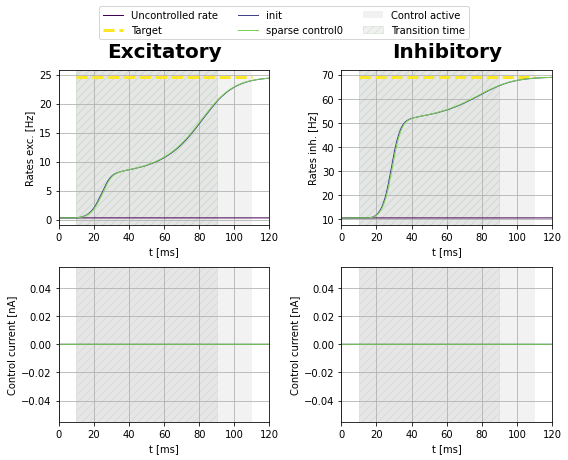

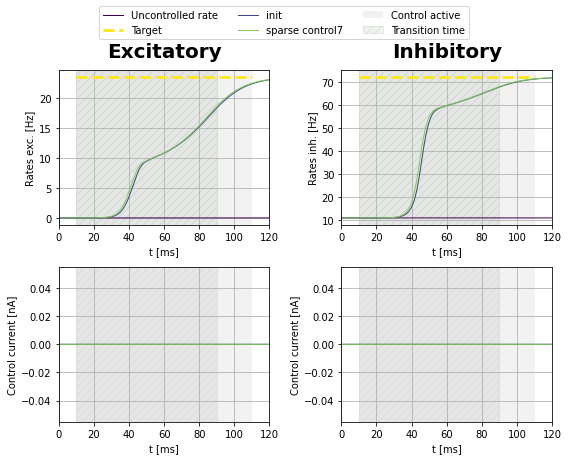

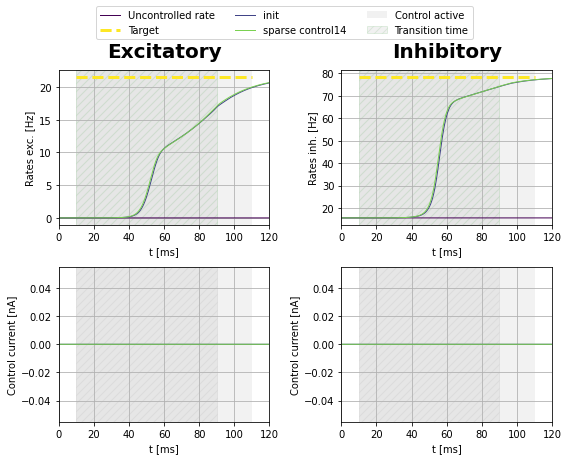

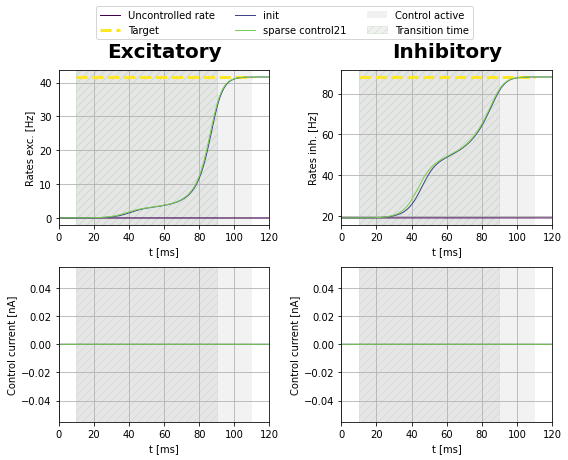

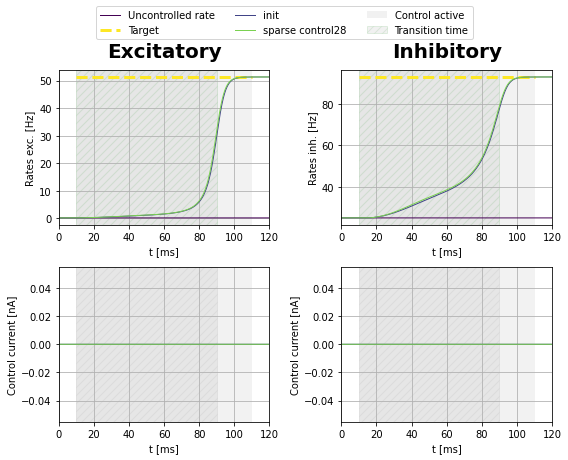

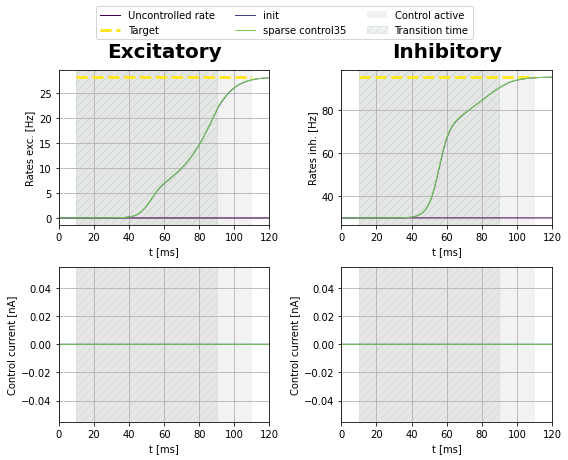

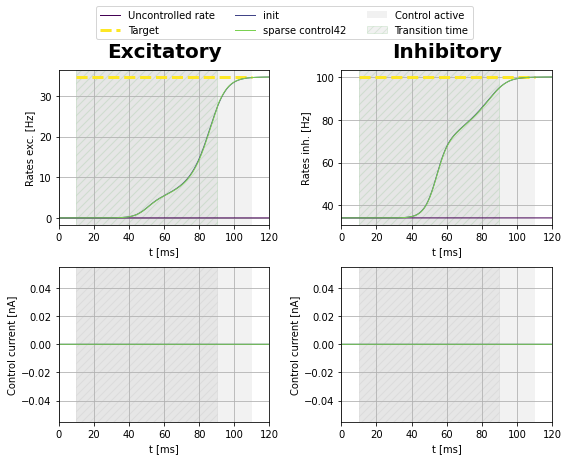

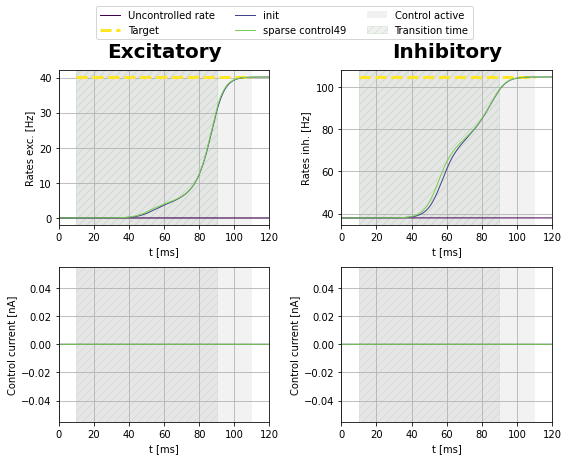

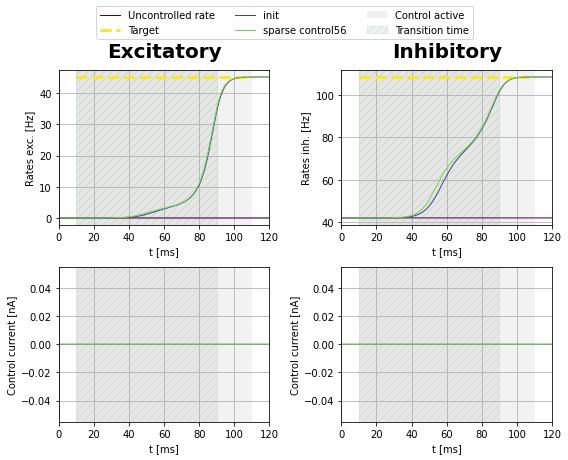

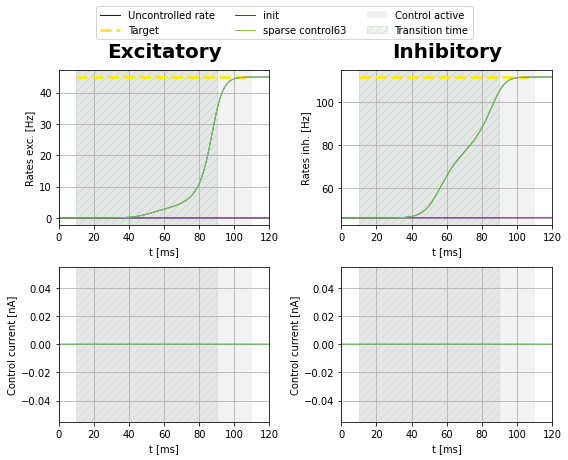

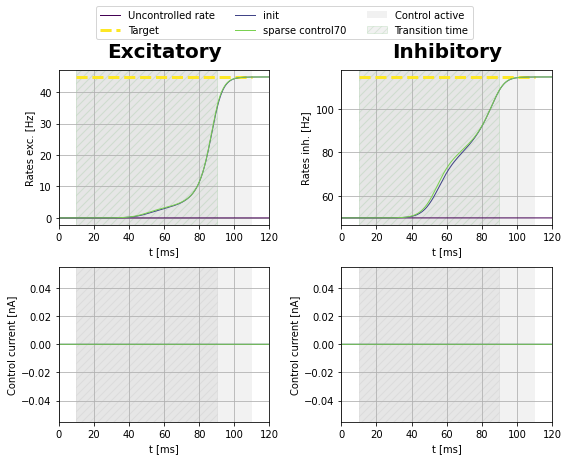

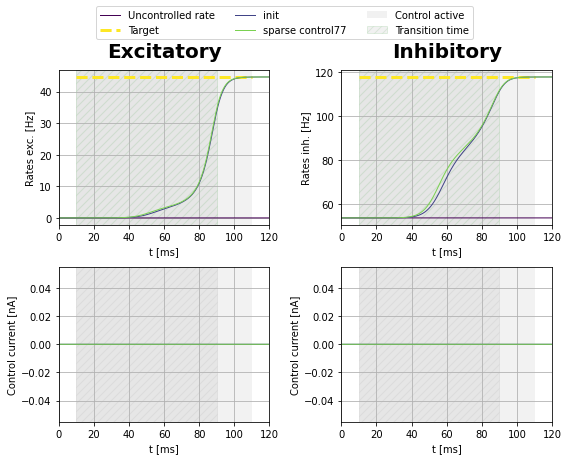

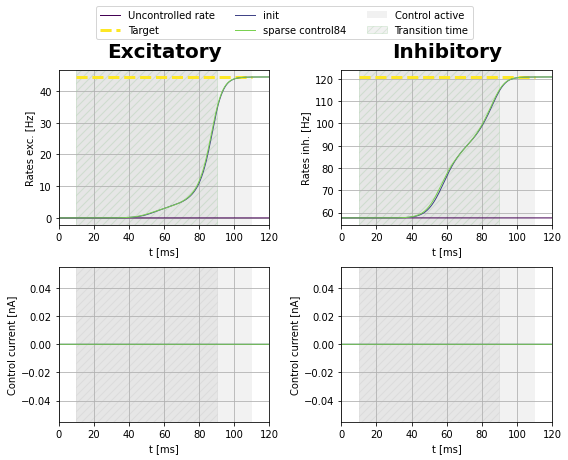

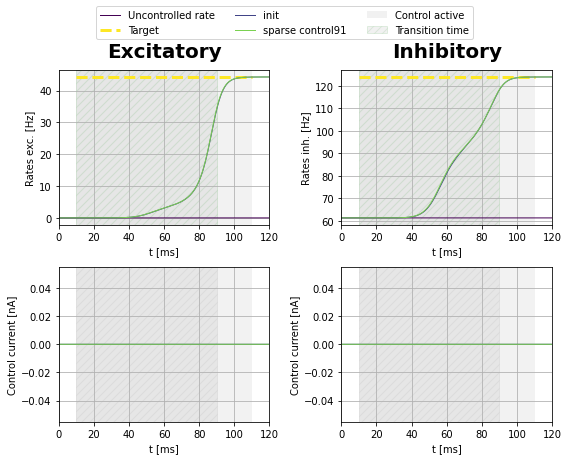

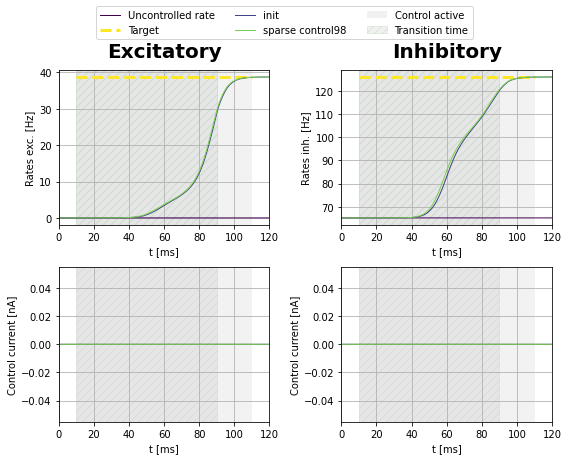

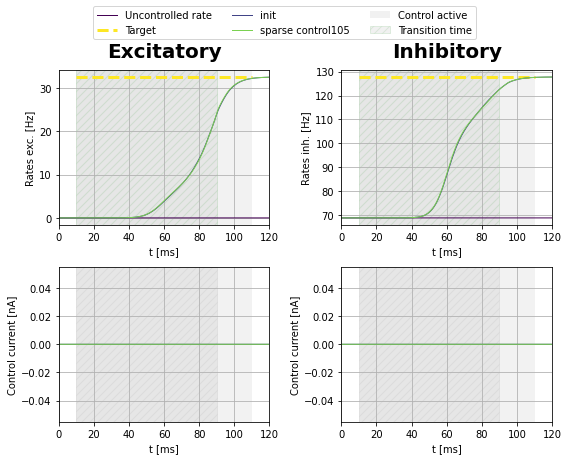

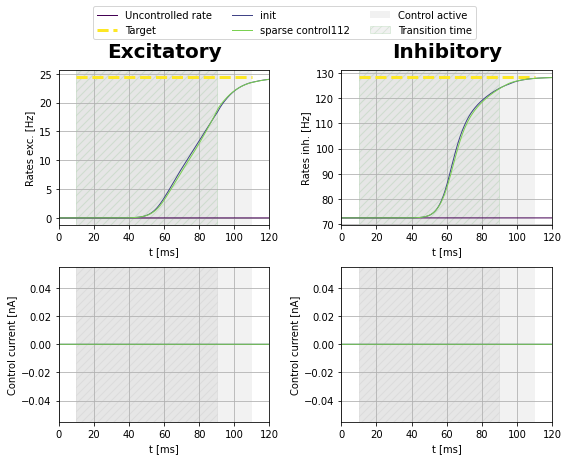

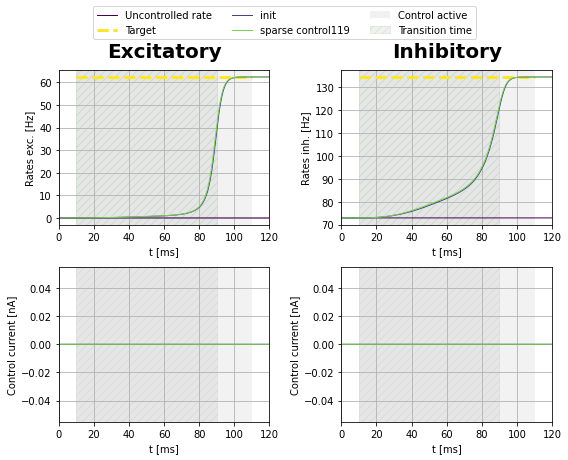

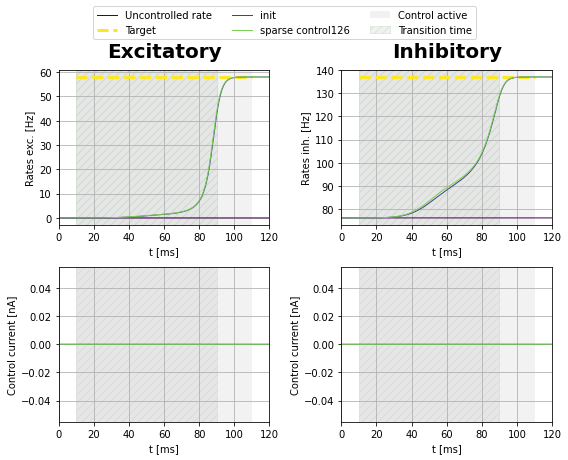

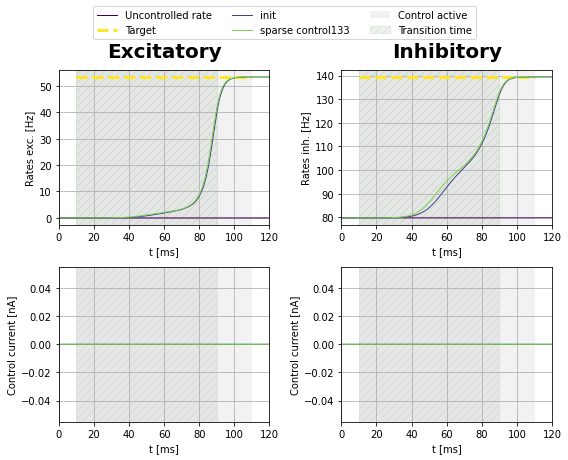

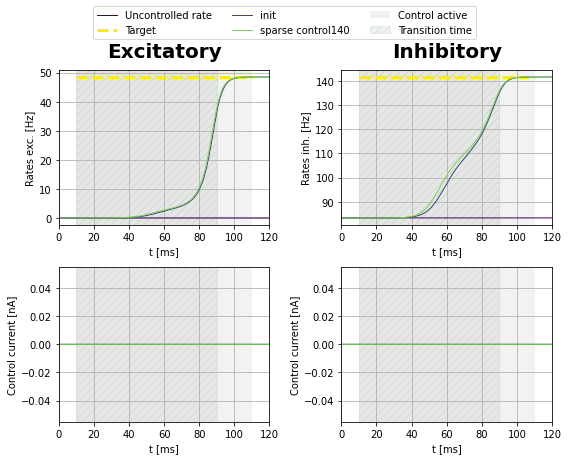

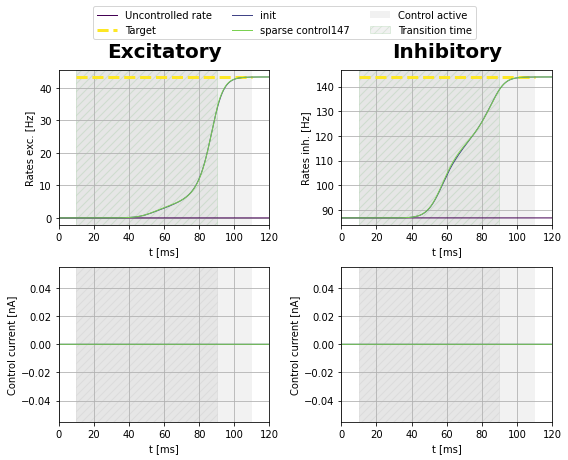

In [19]:
for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [20]:
factor_iteration = 20

for k in range(20):
    for i in i_range:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  375283.77454123856
set cost params:  1.0 0.0 375283.77454123856
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5897.609364027192
Gradient descend method:  None
RUN  1 , total integrated cost =  5897.4412836824395
RUN  2 , total integrated cost =  5897.439983548588
RUN  3 , total integrated cost =  5897.439982935715
RUN  4 , total integrated cost =  5897.439982933922
RUN  5 , total integrated cost =  5897.439982933915


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5897.439982933915
Control only changes marginally.
RUN  6 , total integrated cost =  5897.439982933915
Improved over  6  iterations in  1.8215526267886162  seconds by  0.0028720297127478034  percent.
Problem in initial value trasfer:  sigmae_f 1.6092409664223366 1.6076073016944243
Problem in initial value trasfer:  tau_exc 17.220111838880012 17.238737759018086
Problem in initial value trasfer:  Vmean_exc -56.62665503370225 -56.626662502044574
-------  7 0.4000000000000001 0.3750000000000001
weight =  215398.53139424536
set cost params:  1.0 0.0 215398.53139424536
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5528.955236741557
Gradient descend method:  None
RUN  1 , total integrated cost =  5528.576935570514
RUN  2 , total integrated cost =  5528.572214178004
RUN  3 , total integrated cost =  5528.572065528805
RUN  4 , total integrated cost =  5528.572051969599
RUN  5 , total integrated cost =  5528.572050608998
RUN  6 , total 

ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  5528.572050544
Control only changes marginally.
RUN  14 , total integrated cost =  5528.572050544
Improved over  14  iterations in  3.605763915926218  seconds by  0.006930535357028589  percent.
Problem in initial value trasfer:  Vmean_exc -56.62513161276935 -56.625122034667356
-------  14 0.4000000000000001 0.42500000000000016
weight =  82283.99814326553
set cost params:  1.0 0.0 82283.99814326553
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4636.387715497582
Gradient descend method:  None
RUN  1 , total integrated cost =  4636.303273554773
RUN  2 , total integrated cost =  4636.296622728067
RUN  3 , total integrated cost =  4636.295733843729
RUN  4 , total integrated cost =  4636.295569115228
RUN  5 , total integrated cost =  4636.29552350109
RUN  6 , total integrated cost =  4636.29551027863
RUN  7 , total integrated cost =  4636.295506340645
RUN  8 , total integrated cost =  4636.295505325921
RUN  9 , total integrated cos

...

RUN  1 , total integrated cost =  28476.807909210907
Control only changes marginally.
RUN  1 , total integrated cost =  28476.807909210907
Improved over  1  iterations in  0.3352880608290434  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5012074581886752 1.5012058027751178
Problem in initial value trasfer:  tau_exc 21.37565313828781 21.375662788331795
Problem in initial value trasfer:  Vmean_exc -56.70401542784376 -56.704015476078474
-------  140 0.5250000000000001 0.8750000000000006
weight =  486633.7375642518
set cost params:  1.0 0.0 486633.7375642518
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.58778518953
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23532.58778518953
Control only changes marginally.
RUN  1 , total integrated cost =  23532.58778518953
Improved over  1  iterations in  0.3333699479699135  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.501065940868336 1.5010658408292026
Problem in initial value trasfer:  tau_exc 21.62329444010742 21.623294926806977
Problem in initial value trasfer:  Vmean_exc -56.70066476357846 -56.70066519338603
-------  147 0.5000000000000002 0.9000000000000006
weight =  277169.40747301374
set cost params:  1.0 0.0 277169.40747301374
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18799.726007222183
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  18799.726007222183
Control only changes marginally.
RUN  1 , total integrated cost =  18799.726007222183
Improved over  1  iterations in  0.33854094706475735  seconds by  0.0  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.75797815016926
Problem in initial value trasfer:  Vmean_exc -56.69192745553089 -56.69192969389378


In [21]:
with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)